# Proton analytical models

This notebook demonstrates the two analytical proton-beam models exposed by `pyamtrack`:

- `dose_bortfeld` calculates the absorbed dose profile from the Bortfeld Bragg-curve approximation.
- `let_wilkens` calculates dose-averaged (`LET_d`) and track-averaged (`LET_t`) linear energy transfer using the Wilkens & Oelfke model.

Both models accept depth, energy spread, and material arguments in physical units.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import pyamtrack

## Beam and material setup

The example uses a 150 MeV proton beam in liquid water with a 1% relative energy spread. The depth range includes the Bragg peak while staying within the range where the LET model returns finite values.

In [2]:
depth_cm = np.linspace(0.0, 17.0, 500)
energy_MeV = 150.0
energy_spread_fraction = 0.01  # 1% relative energy spread

# Parameters used by the Bortfeld dose model.
fluence_cm2 = 1e8
eps = 0.03  # fraction assigned to the nuclear interaction tail

## Bortfeld dose profile

The result is absorbed dose in Gy as a function of depth. Keyword arguments make the units and model inputs explicit.

In [3]:
dose_Gy = pyamtrack.proton_models.dose_bortfeld(
    depth_cm=depth_cm,
    fluence_cm2=fluence_cm2,
    energy_MeV=energy_MeV,
    energy_spread_fraction=energy_spread_fraction,
    material=pyamtrack.materials.water_liquid,
    eps=eps,
    cartesian_product=False,
)

dose_Gy.shape, float(dose_Gy.min()), float(dose_Gy.max())

((500,), 2.3308991041760143e-05, 0.3791595067693188)

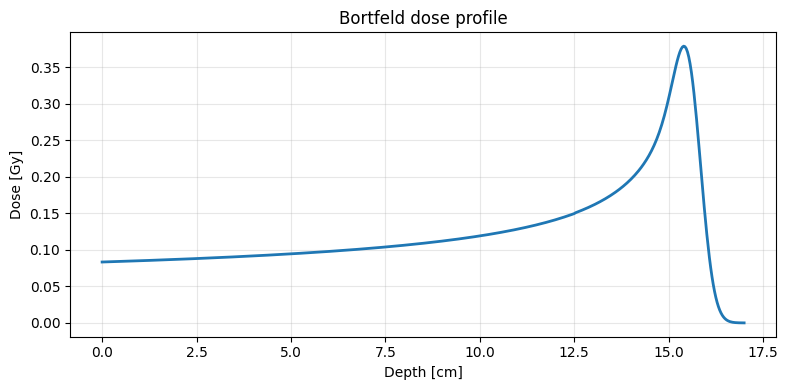

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(depth_cm, dose_Gy, lw=2, color="tab:blue")
ax.set_title("Bortfeld dose profile")
ax.set_xlabel("Depth [cm]")
ax.set_ylabel("Dose [Gy]")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Wilkens LET profiles

`let_wilkens` supports two averaging conventions. Dose-averaged LET is commonly used for RBE calculations, while track-averaged LET is the fluence-weighted mean stopping power. The enum values below are equivalent to passing `averaging="dose"` and `averaging="track"`.

In [5]:
let_d_keV_um = pyamtrack.proton_models.let_wilkens(
    depth_cm=depth_cm,
    energy_MeV=energy_MeV,
    energy_spread_fraction=energy_spread_fraction,
    material=pyamtrack.materials.water_liquid,
    averaging=pyamtrack.proton_models.Averaging.DOSE,
    cartesian_product=False,
)

let_t_keV_um = pyamtrack.proton_models.let_wilkens(
    depth_cm=depth_cm,
    energy_MeV=energy_MeV,
    energy_spread_fraction=energy_spread_fraction,
    material=pyamtrack.materials.water_liquid,
    averaging=pyamtrack.proton_models.Averaging.TRACK,
    cartesian_product=False,
)

let_d_keV_um.shape, let_t_keV_um.shape

((500,), (500,))

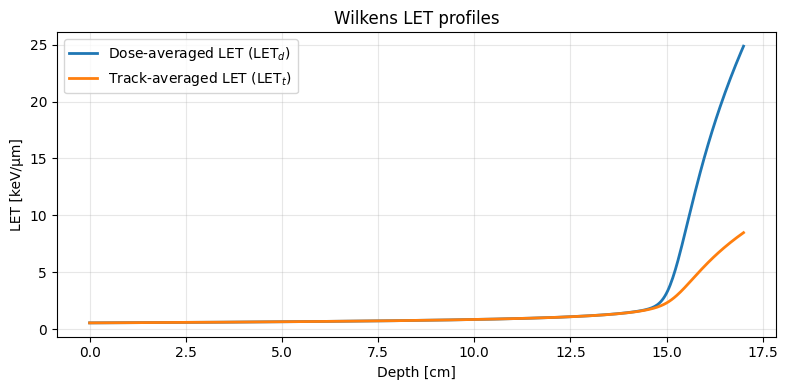

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(depth_cm, let_d_keV_um, lw=2, label="Dose-averaged LET (LET$_d$)")
ax.plot(depth_cm, let_t_keV_um, lw=2, label="Track-averaged LET (LET$_t$)")
ax.set_title("Wilkens LET profiles")
ax.set_xlabel("Depth [cm]")
ax.set_ylabel("LET [keV/µm]")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

Near the Bragg peak, `LET_d` rises above `LET_t` because dose averaging gives more weight to high-energy-deposition tracks. To evaluate several parameter combinations at once, pass arrays and set `cartesian_product=True`; the result is shaped by the iterable arguments.